# Feature Relationship
* it means understanding how two or more variables (features) in a dataset are connected or influence each other.
#### why it is important
* feature selection
* find patterns
* remove redundant items
* improve predictions...

In [2]:
import pandas as pd

# Creates a sample DataFrame
data = {
    "Age": [20, 25, 30, 35, 40],
    "Salary": [25000, 30000, 40000, 50000, 60000],
    "Experience": [1, 2, 5, 7, 10]
}

df = pd.DataFrame(data)
correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

                 Age    Salary  Experience
Age         1.000000  0.993884    0.989762
Salary      0.993884  1.000000    0.997965
Experience  0.989762  0.997965    1.000000


# Corelation Matrix
* A correlation matrix shows how strongly different variables are related to each other.
*  Values range from -1 to +1.
### Real-time example:
 * A company checks the relationship between advertising spend, sales, website visits, and customers to understand which variables move together.

### formula
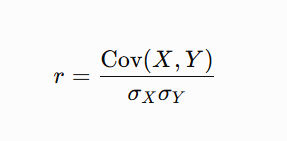

In [3]:
import pandas as pd

correlation_matrix = df.corr()
print(correlation_matrix)

                 Age    Salary  Experience
Age         1.000000  0.993884    0.989762
Salary      0.993884  1.000000    0.997965
Experience  0.989762  0.997965    1.000000


# Multicollinearity
* Multicollinearity happens when two or more independent variables in a model are highly related to each other.
* This can make it difficult to understand the individual effect of each variable.
### Real-time example:
 In a house-price model, house size and number of rooms may be highly related, causing multicollinearity.

 ### example
 

In [5]:
correlation = df.corr(numeric_only=True)

print(correlation)

                 Age    Salary  Experience
Age         1.000000  0.993884    0.989762
Salary      0.993884  1.000000    0.997965
Experience  0.989762  0.997965    1.000000


# Variance Inflation Factor (VIF)
* VIF measures how much a variable is affected by multicollinearity with other variables. 
* A high VIF indicates that the variable has strong relationships with other predictors.
### Real-time example: 
* In a sales prediction model, if advertising spend has a VIF of 10, it may be highly related to other input variables.
### Formula:

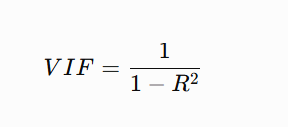

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["Experience", "Age"]]

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

      Feature       VIF
0  Experience  8.333742
1         Age  8.333742


# Feature Importance
* Feature importance tells us which input variables are most useful for predicting the target variable
*  Higher importance generally means the model relies more on that feature.
### Real-time example: 
* In a customer-churn model, monthly charges may be more important than customer age for predicting whether a customer will leave.

In [8]:
from sklearn.ensemble import RandomForestRegressor

X = df[["Experience", "Age"]]
y = df["Salary"]

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(importance)

      Feature  Importance
0  Experience    0.502623
1         Age    0.497377


# Feature Selection Basics
* Feature selection means choosing the most useful variables for a machine-learning model and removing unnecessary or duplicate variables.
* It can make the model simpler and sometimes improve performance.
### Real-time example:
* For predicting employee salary, useful features might be experience, education, and job level, while an employee ID may be unnecessary.

#### Why is it Important?
* Improves model accuracy.
* Reduces training time.
* Prevents overfitting.
* Simplifies the model.

### example


In [9]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X, y)

print(X_selected)

[[ 1 20]
 [ 2 25]
 [ 5 30]
 [ 7 35]
 [10 40]]


C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=3 is greater than n_features=2. All the features will be returned.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:109: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


In [10]:
selected_features = df[["Experience", "Age"]]

print(selected_features)

   Experience  Age
0           1   20
1           2   25
2           5   30
3           7   35
4          10   40
